# Data Quality Validation & Profiling

This notebook covers 8 dimensions: Completeness, Uniqueness, Consistency, Accuracy, Outlier Detection (Z-score, IQR, Isolation Forest), Distribution Profiling, Relationships Profiling, and Report Generation.

## 1. Environment Setup and Data Loading
Import essential libraries and load the dataset into a DataFrame.

In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
# Adjust the path if necessary
file_path = '../OSM/all_properties_with_osm.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Data loaded successfully! Shape: {df.shape}")
except FileNotFoundError:
    print("File not found. Please verify the path.")
    # Creating a dummy dataframe for demonstration if file not found
    df = pd.DataFrame({'price': np.random.normal(100, 20, 100), 'area': np.random.normal(50, 10, 100), 'id': range(100)})

# Dictionary to hold report summaries
report_summary = {}

Data loaded successfully! Shape: (71405, 66)


## 2. Accuracy Validation
Verify data types against expected schemas and check numerical values against acceptable domain limits (e.g., price > 0).

In [8]:
print("--- Accuracy Validation ---")
accuracy_issues = 0

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    # Assuming physical quantities (like area, price, etc.) shouldn't be negative generally
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"Warning: Column '{col}' contains {negative_count} negative values.")
        accuracy_issues += negative_count

if accuracy_issues == 0:
    print("Basic numeric boundaries look accurate (no negative values where positive expected).")

report_summary['Accuracy'] = f"{accuracy_issues} basic numerical boundary violations found."
print(f"Result: {report_summary['Accuracy']}")

--- Accuracy Validation ---
Basic numeric boundaries look accurate (no negative values where positive expected).
Result: 0 basic numerical boundary violations found.


## 3. Consistency Validation\n
Apply logical checks across columns. (Add custom specific logical checks here).

In [9]:
print("--- Consistency Validation ---")
consistency_errors = []
total_records = len(df)

# 1. Capitalization Consistency Checks (e.g. "cairo" vs "Cairo")
categorical_cols = ['city', 'town', 'district', 'property_type', 'listing_type']
for col in categorical_cols:
    if col in df.columns:
        # Check if converting to lowercase reduces the number of unique values
        lower_vals = df[col].dropna().astype(str).str.lower()
        original_unique = df[col].nunique()
        lower_unique = lower_vals.nunique()
        if original_unique > lower_unique:
            inconsistent_caps = original_unique - lower_unique
            print(f"[{col}] Found {inconsistent_caps} capitalization discrepancies.")
            consistency_errors.append(f"{col} capitalization mismatch")

# 2. Units Uniformity Checks (e.g. mixing meters and feet, or currencies)
units_cols = ['area_unit', 'price_currency']
for col in units_cols:
    if col in df.columns:
        unique_units = df[col].dropna().unique()
        if len(unique_units) > 1:
            print(f"[{col}] Inconsistent units found in the same column: {unique_units}")
            consistency_errors.append(f"Mixed {col}")

# 3. Logical/Relational Consistency 
# (e.g. area vs bedrooms, reasonable values)
if 'area_value' in df.columns and 'bedrooms' in df.columns:
    # Check for properties with 3+ bedrooms but exceptionally small areas (< 20 units)
    bad_area_beds = df[(pd.to_numeric(df['bedrooms'], errors='coerce') > 2) & 
                       (pd.to_numeric(df['area_value'], errors='coerce') < 25)]
    if len(bad_area_beds) > 0:
        print(f"[Logic Check] Found {len(bad_area_beds)} records with illogical area-to-bedroom ratios.")
        consistency_errors.append("Illogical area vs bedrooms")

# 4. Mixed Data Types Consistency (Checking for string values in expected numeric columns)
expected_numeric_cols = ['bedrooms', 'bathrooms', 'price', 'area_value', 'parking_spaces', 'floor_level']
for col in expected_numeric_cols:
    if col in df.columns:
        # Find values that cannot be converted to numeric
        non_numeric_mask = pd.to_numeric(df[col], errors='coerce').isna()
        # Keep non-numeric values that are not actually just empty/NaN themselves
        non_numeric_vals = df.loc[non_numeric_mask & df[col].notna(), col].unique()
        
        if len(non_numeric_vals) > 0:
            print(f"[{col.capitalize()} Consistency] Found non-numeric values (e.g., strings) in {col}: {non_numeric_vals}")
            consistency_errors.append(f"Mixed types in {col}")

report_summary['Consistency'] = f"{len(consistency_errors)} types of consistency issues found."
print(f"\nTotal structural consistency issues flagged: {len(consistency_errors)}")
print(f"Result: {report_summary['Consistency']}")

--- Consistency Validation ---
[district] Found 7 capitalization discrepancies.
[area_unit] Inconsistent units found in the same column: <StringArray>
['sqm', 'SQM']
Length: 2, dtype: str
[Logic Check] Found 1074 records with illogical area-to-bedroom ratios.
[Bedrooms Consistency] Found non-numeric values (e.g., strings) in bedrooms: ['studio' '7+']

Total structural consistency issues flagged: 4
Result: 4 types of consistency issues found.


## 4. Completeness Analysis\n
Calculate the percentage of missing values per column and identify rows with significant data gaps.

In [10]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
completeness_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percent})
completeness_df = completeness_df[completeness_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("--- Completeness Analysis ---")
print(completeness_df)

report_summary['Completeness'] = f"{len(completeness_df)} columns have missing values."
print(f"Result: {report_summary['Completeness']}")

--- Completeness Analysis ---
                   Missing Values  Percentage (%)
rera                        71405      100.000000
video_url                   71203       99.717107
agent_languages             62639       87.723549
payment_plan                52022       72.854842
broker_email                33821       47.365030
amenities                   33657       47.135355
agent_email                 33627       47.093341
is_exclusive                33627       47.093341
description                 33627       47.093341
price_period                33627       47.093341
subdistrict                 29158       40.834675
completion_status           18566       26.000980
furnished                   13358       18.707373
agent_is_verified            6188        8.666060
district                     5258        7.363630
contact_whatsapp              519        0.726840
broker_phone                  224        0.313704
bedrooms                       32        0.044815
contact_phone       

## 5. Uniqueness Analysis\n
Detect and quantify exact duplicate rows and compute the cardinality of categorical features.

In [11]:
duplicates_count = df.duplicated().sum()
duplicates_percent = (duplicates_count / len(df)) * 100

print("--- Uniqueness Analysis ---")
print(f"Exact duplicate rows: {duplicates_count} ({duplicates_percent:.2f}%)")

# Cardinality of categorical features
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
cardinality = {col: df[col].nunique() for col in categorical_cols}
print("\nCardinality of Categorical Columns:")
for col, count in cardinality.items():
    print(f"{col}: {count} unique values")

report_summary['Uniqueness'] = f"{duplicates_count} duplicate rows found."
print(f"Result: {report_summary['Uniqueness']}")

--- Uniqueness Analysis ---
Exact duplicate rows: 0 (0.00%)

Cardinality of Categorical Columns:
listing_id: 71405 unique values
internal_id: 71269 unique values
category: 3 unique values
listing_type: 15 unique values
detail_url: 71405 unique values
property_type: 33 unique values
offering_type: 3 unique values
completion_status: 5 unique values
title: 64868 unique values
price_period: 2 unique values
price_currency: 1 unique values
location_full: 3354 unique values
city: 22 unique values
town: 161 unique values
district: 1250 unique values
subdistrict: 1470 unique values
bedrooms: 24 unique values
bathroom: 33 unique values
area_unit: 2 unique values
furnished: 5 unique values
listing_level: 5 unique values
is_exclusive: 1 unique values
listed_date: 67957 unique values
video_url: 154 unique values
reference: 71002 unique values
description: 34733 unique values
amenities: 17438 unique values
payment_plan: 3 unique values
agent_id: 6038 unique values
agent_name: 4796 unique values
agen

## 6. Outlier Detection using Z-Score
Flag records that fall outside of a specified standard deviation.

In [12]:
print("--- Outlier Detection: Z-Score ---")
z_threshold = 3.0
z_outliers = pd.DataFrame()

for col in numeric_cols:
    # Ignore id-like columns and NaN values
    if df[col].nunique() > 10 and not col.lower().endswith('id'):
        col_data = df[col].dropna()
        z_scores = np.abs(stats.zscore(col_data))
        outliers = col_data[z_scores > z_threshold]
        print(f"{col}: {len(outliers)} outliers detected (Z-score > {z_threshold})")
        
report_summary['Z-Score Outliers'] = "Z-score evaluated for numeric columns."
print(f"Result: {report_summary['Z-Score Outliers']}")

--- Outlier Detection: Z-Score ---
price_egp: 513 outliers detected (Z-score > 3.0)
lat: 3301 outliers detected (Z-score > 3.0)
lon: 2308 outliers detected (Z-score > 3.0)
area_value: 161 outliers detected (Z-score > 3.0)
images_count: 1574 outliers detected (Z-score > 3.0)
broker_phone: 0 outliers detected (Z-score > 3.0)
contact_phone: 1 outliers detected (Z-score > 3.0)
contact_whatsapp: 0 outliers detected (Z-score > 3.0)
dist_nearest_school_km: 2101 outliers detected (Z-score > 3.0)
school_count_within_3km: 1938 outliers detected (Z-score > 3.0)
dist_nearest_hospital_km: 3249 outliers detected (Z-score > 3.0)
hospital_count_within_3km: 2337 outliers detected (Z-score > 3.0)
dist_nearest_supermarket_km: 2008 outliers detected (Z-score > 3.0)
supermarket_count_within_3km: 3239 outliers detected (Z-score > 3.0)
dist_nearest_mall_km: 2636 outliers detected (Z-score > 3.0)
dist_nearest_transit_station_km: 1319 outliers detected (Z-score > 3.0)
transit_station_count_within_3km: 1520 out

## 7. Outlier Detection using IQR
Compute the Interquartile Range and identify outliers beyond the 1.5 * IQR bounds.

In [13]:
print("--- Outlier Detection: IQR ---")
iqr_outliers_summary = {}

for col in numeric_cols:
    if df[col].nunique() > 10 and not col.lower().endswith('id'):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"{col}: {len(outliers)} outliers detected using IQR method")
        iqr_outliers_summary[col] = len(outliers)
        
report_summary['IQR Outliers'] = "IQR calculated for numeric columns."
print(f"Result: {report_summary['IQR Outliers']}")

--- Outlier Detection: IQR ---
price_egp: 4107 outliers detected using IQR method
lat: 12559 outliers detected using IQR method
lon: 10477 outliers detected using IQR method
area_value: 4969 outliers detected using IQR method
images_count: 8948 outliers detected using IQR method
broker_phone: 10213 outliers detected using IQR method
contact_phone: 2243 outliers detected using IQR method
contact_whatsapp: 0 outliers detected using IQR method
dist_nearest_school_km: 9616 outliers detected using IQR method
school_count_within_3km: 5864 outliers detected using IQR method
dist_nearest_hospital_km: 8926 outliers detected using IQR method
hospital_count_within_3km: 6517 outliers detected using IQR method
dist_nearest_supermarket_km: 8176 outliers detected using IQR method
supermarket_count_within_3km: 12673 outliers detected using IQR method
dist_nearest_mall_km: 7849 outliers detected using IQR method
dist_nearest_transit_station_km: 1473 outliers detected using IQR method
transit_station_co

## 9. Distribution Profiling
Generate statistical summaries, histograms, and density plots to analyze the univariate distribution.

--- Distribution Profiling ---


,price_egp,lat,lon,area_value,images_count,rera,broker_id,broker_phone,contact_phone,contact_whatsapp,...,dist_nearest_hospital_km,hospital_count_within_3km,dist_nearest_supermarket_km,supermarket_count_within_3km,dist_nearest_mall_km,mall_count_within_3km,dist_nearest_transit_station_km,transit_station_count_within_3km,dist_nearest_cafe_restaurant_km,cafe_restaurant_count_within_3km
count,7.140500e+04,71405.000000,71405.000000,71405.000000,71405.000000,0.0,71405.000000,7.118100e+04,7.137500e+04,7.088600e+04,...,71405.000000,71405.000000,71405.000000,71405.000000,71405.000000,71405.000000,71405.000000,71405.000000,71405.000000,71405.000000
mean,1.138198e+07,29.981210,31.255680,266.666648,12.121210,NaN,8399.092613,1.749965e+11,1.687795e+14,1.270482e+11,...,9.906414,2.366655,4.723948,7.792648,16.793087,0.608123,5.494010,1.000168,3.425623,13.170744
std,2.726821e+07,0.701307,1.015430,1467.448118,4.743487,NaN,10970.987493,6.738524e+10,4.503757e+16,8.895113e+10,...,18.903603,6.438108,6.935079,15.563287,40.270902,1.291969,4.036463,3.784438,5.978542,29.802072
min,1.300000e+03,25.069366,25.476135,1.000000,1.000000,NaN,3.000000,1.000009e+09,2.010022e+10,2.050008e+08,...,0.010000,0.000000,0.009000,0.000000,0.066000,0.000000,0.005000,0.000000,0.002000,0.000000
25%,2.431660e+05,29.995922,30.998248,130.000000,10.000000,NaN,2290.000000,2.010120e+11,2.010338e+11,2.022126e+10,...,1.691000,0.000000,1.031000,0.000000,2.449000,0.000000,3.116000,0.000000,0.791000,0.000000
50%,6.500000e+06,30.028351,31.483500,173.000000,11.000000,NaN,4965.000000,2.010708e+11,2.011010e+11,2.010800e+11,...,3.893000,0.000000,2.365000,1.000000,4.383000,0.000000,4.865000,0.000000,1.565000,3.000000
75%,1.360000e+07,30.071285,31.572048,244.000000,13.000000,NaN,14109.000000,2.011411e+11,2.011493e+11,2.011036e+11,...,7.118000,2.000000,4.723000,5.000000,7.248000,1.000000,7.426000,0.000000,3.225000,11.000000
max,1.885000e+09,31.497467,34.896572,134400.000000,76.000000,NaN,179957.000000,2.015599e+11,1.203228e+19,2.015600e+11,...,284.592000,61.000000,305.035000,96.000000,489.463000,10.000000,90.306000,40.000000,77.675000,256.000000


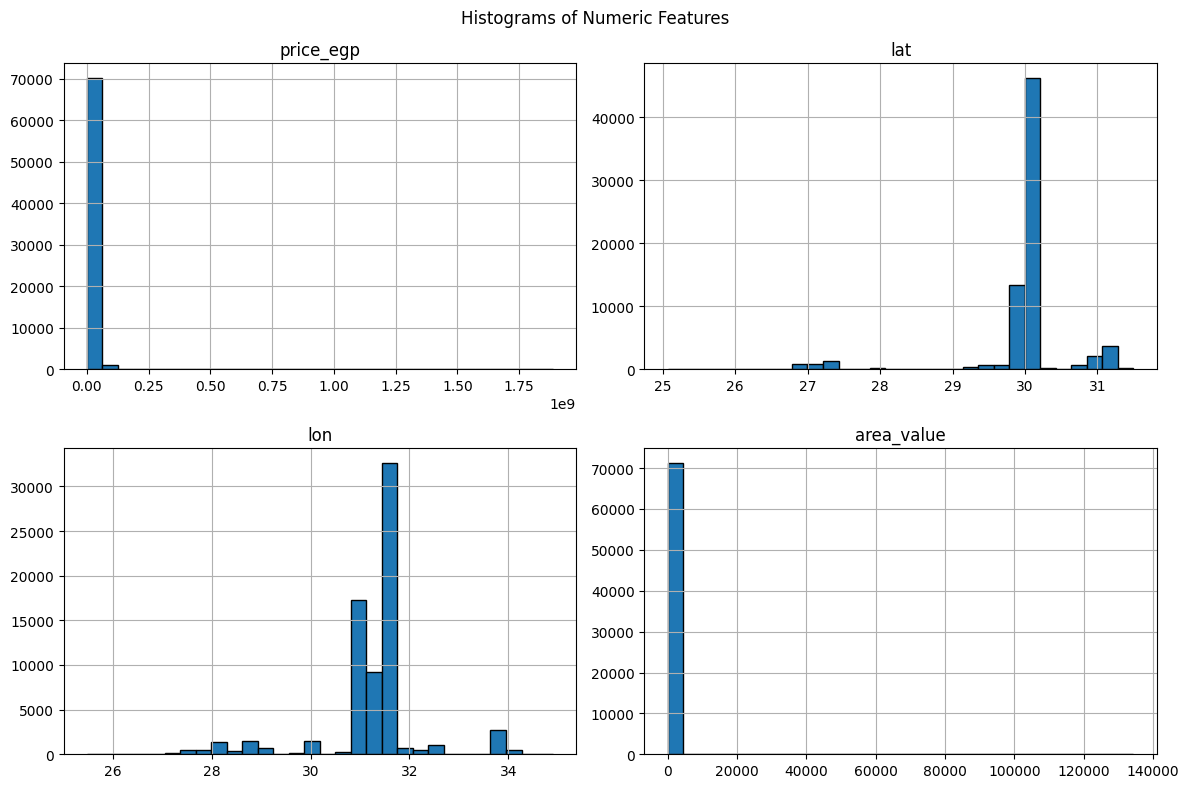

Result: Summary statistics and histograms generated.


In [15]:
print("--- Distribution Profiling ---")
display(df.describe())

# Select a few numeric columns to plot histograms
cols_to_plot = numeric_cols[:4]  # taking up to 4 columns to keep plot clean
df[cols_to_plot].hist(bins=30, figsize=(12, 8), edgecolor='black')
plt.suptitle('Histograms of Numeric Features')
plt.tight_layout()
plt.show()

report_summary['Distribution'] = "Summary statistics and histograms generated."
print(f"Result: {report_summary['Distribution']}")

## 10. Relationships Profiling
Compute correlation matrices and generate pair plots to identify relationships.

--- Relationships Profiling ---


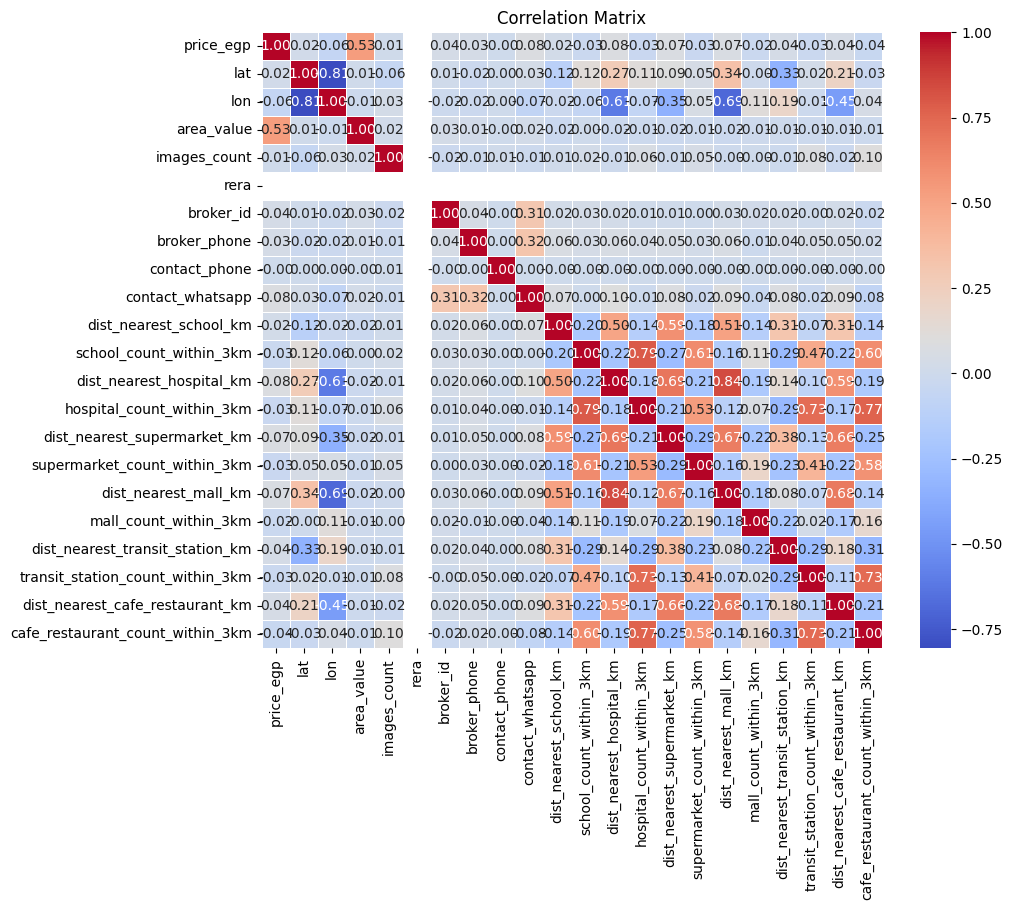

Result: Correlation matrix evaluated.


In [16]:
print("--- Relationships Profiling ---")

if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.show()
    
    report_summary['Relationships'] = "Correlation matrix evaluated."
else:
    print("Not enough numeric columns for relationship profiling.")
    report_summary['Relationships'] = "Insufficient numeric columns."
print(f"Result: {report_summary['Relationships']}")

## 11. Dataset Context: Features, Target, and Classes
This section outlines the dataset context to easily extract for the final report:
- **Feature Descriptions**: Reviewing the schemas and data dictionaries.
- **Target Definition**: Identifying the primary prediction target (e.g., `price`).
- **Engineered Features**: Identifying features derived from external data (e.g., OSM).
- **Class Distribution**: Checking the balance of primary categorical variables.

--- Feature Descriptions ---
<class 'pandas.DataFrame'>
RangeIndex: 71405 entries, 0 to 71404
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   listing_id                        71405 non-null  object 
 1   internal_id                       71405 non-null  object 
 2   category                          71405 non-null  str    
 3   listing_type                      71405 non-null  str    
 4   detail_url                        71405 non-null  str    
 5   property_type                     71405 non-null  str    
 6   offering_type                     71405 non-null  str    
 7   completion_status                 52839 non-null  str    
 8   title                             71405 non-null  str    
 9   price_egp                         71405 non-null  float64
 10  price_period                      37778 non-null  str    
 11  price_currency                    71405 non-null 

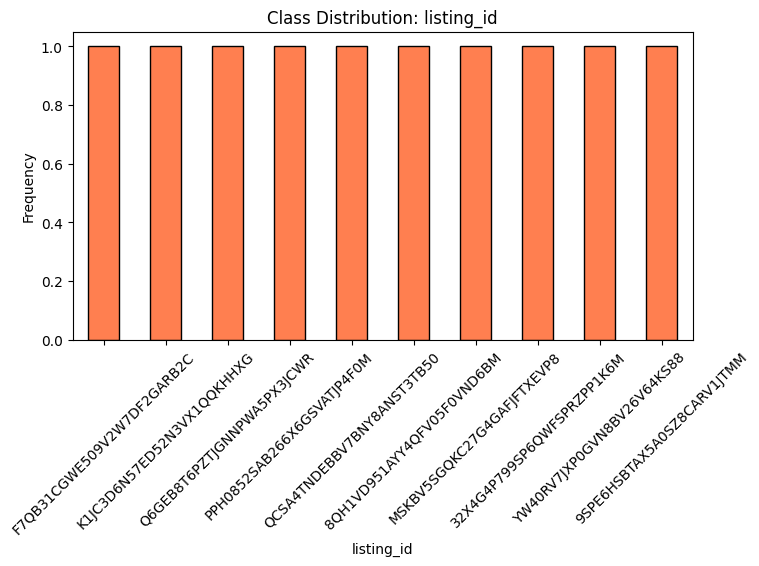

In [17]:
print("--- Feature Descriptions ---")
df.info()
report_summary['Feature Descriptions'] = f"Dataset contains {df.shape[0]} rows and {df.shape[1]} features."

print("\n--- Target Definition ---")
target_col = 'price' # Standardizing on price for real-estate datasets
if target_col in df.columns:
    print(f"Primary Target Variable: '{target_col}'")
    report_summary['Target Definition'] = f"Target defined as '{target_col}'."
else:
    print("Target variable not explicitly found.")
    report_summary['Target Definition'] = "Target variable undefined."

print("\n--- Engineered Features ---")
# Check for OSM or distance related columns commonly engineered
engineered_cols = [col for col in df.columns if any(kw in col.lower() for kw in ['osm', 'dist', 'nearest', 'count'])]
print(f"Identified {len(engineered_cols)} potential engineered features.")
report_summary['Engineered Features'] = f"{len(engineered_cols)} engineered features identified (e.g., OSM data)."

print("\n--- Class Distribution ---")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
if len(categorical_cols) > 0:
    for col in categorical_cols[:2]: # Show top 2 for brevity
        print(f"\nTop 5 Classes for '{col}':")
        print(df[col].value_counts(normalize=True).head() * 100)
    
    # Simple visual for the primary class
    plt.figure(figsize=(8, 4))
    df[categorical_cols[0]].value_counts().head(10).plot(kind='bar', color='coral', edgecolor='black')
    plt.title(f'Class Distribution: {categorical_cols[0]}')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()
    
    report_summary['Class Distribution'] = f"Class metrics generated for {len(categorical_cols)} categorical variables."
else:
    print("No categorical columns available for class distribution.")
    report_summary['Class Distribution'] = "No categorical classes to distribute."

## 12. Generate Data Quality Report
Aggregate the metrics and findings into a structured summary DataFrame.

In [18]:
print("====================================")
print("       DATA QUALITY REPORT          ")
print("====================================")

report_df = pd.DataFrame(list(report_summary.items()), columns=['Dimension', 'Findings / Summary'])
display(report_df)

# Optionally, export to CSV
# report_df.to_csv('data_quality_report.csv', index=False)
print("Report generation complete.")

       DATA QUALITY REPORT          


,Dimension,Findings / Summary
0,Accuracy,0 basic numerical boundary violations found.
1,Consistency,4 types of consistency issues found.
2,Completeness,21 columns have missing values.
3,Uniqueness,0 duplicate rows found.
4,Z-Score Outliers,Z-score evaluated for numeric columns.
5,IQR Outliers,IQR calculated for numeric columns.
6,Isolation Forest,Insufficient data.
7,Distribution,Summary statistics and histograms generated.
8,Relationships,Correlation matrix evaluated.
9,Feature Descriptions,Dataset contains 71405 rows and 66 features.


Report generation complete.
